# Huấn luyện lại mô hình gợi ý cây trồng (v2)

Notebook này huấn luyện lại mô hình theo hướng khách quan hơn: nested CV cho validation và test hold-out 20% để báo cáo cuối.

## Mục tiêu
- Tiền xử lý dữ liệu trước train: xử lý null/NaN, loại trùng, xử lý ngoại lai.
- Trực quan hóa dữ liệu trước và sau làm sạch.
- Huấn luyện và so sánh 4 mô hình: Random Forest, Naive Bayes, KNN, SVM.
- Tách rõ validation/testing và phân tích trade-off precision/recall/F1.
- Bổ sung biểu đồ `accuracy_train` vs `accuracy_val` theo fold để quan sát overfitting.
- Lưu artifact phiên bản mới (model + scaler + log metrics) để deploy vào predict server.

## Cấu trúc quy trình
1. Thiết lập môi trường và import thư viện.
2. Khai báo cấu hình tập trung.
3. Nạp dữ liệu và kiểm tra chất lượng.
4. Tiền xử lý và trực quan hóa trước train.
5. Cài đặt hàm lõi cho nested CV + testing.
6. Chạy huấn luyện/validation/testing và lưu lịch sử.
7. Đánh giá kết quả bằng nhiều biểu đồ trade-off.
8. Lưu artifact phiên bản mới và smoke test mô hình đã lưu.

In [2]:
# 1) Thiết lập môi trường và import thư viện
import pickle
import json
import time
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# Thiết lập giao diện biểu đồ phục vụ báo cáo.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print("Đã sẵn sàng môi trường")
print(f"numpy={np.__version__}")
print(f"pandas={pd.__version__}")
print(f"seaborn={sns.__version__}")

Đã sẵn sàng môi trường
numpy=2.3.3
pandas=2.3.3
seaborn=0.13.2


## 2) Khai báo cấu hình và tham số chạy

Toàn bộ tham số được gom vào một cấu hình trung tâm để dễ tái lập và thay đổi.

Lưu ý tương thích production hiện tại:
- Thứ tự scaler phải là **MinMaxScaler -> StandardScaler**.
- Mục tiêu (label) được map về ID cố định 1..22 để khớp với predict server.

In [3]:
@dataclass
class TrainConfig:
    random_seed: int = 42
    test_size: float = 0.2
    outer_folds: int = 5
    inner_folds: int = 3
    dataset_path: str = "./Crop_recommendation.csv"
    model_root: str = "./models"
    output_root: str = "./training_outputs"

    rf_params: dict = None
    knn_params: dict = None
    svm_params: dict = None
    dt_params: dict = None
    logreg_params: dict = None
    bagging_params: dict = None

    def __post_init__(self):
        if self.rf_params is None:
            self.rf_params = {
                "n_estimators": 400,
                "max_depth": None,
                "min_samples_split": 2,
                "min_samples_leaf": 1,
                "random_state": self.random_seed,
                "n_jobs": -1,
            }
        if self.knn_params is None:
            self.knn_params = {
                "n_neighbors": 9,
                "weights": "distance",
                "metric": "minkowski",
            }
        if self.svm_params is None:
            self.svm_params = {
                "kernel": "rbf",
                "C": 10,
                "gamma": "scale",
                "probability": True,
                "random_state": self.random_seed,
            }
        if self.dt_params is None:
            self.dt_params = {
                "criterion": "gini",
                "max_depth": 18,
                "min_samples_split": 4,
                "min_samples_leaf": 2,
                "random_state": self.random_seed,
            }
        if self.logreg_params is None:
            self.logreg_params = {
                "solver": "lbfgs",
                "C": 2.0,
                "max_iter": 4000,
                "multi_class": "multinomial",
                "random_state": self.random_seed,
            }
        if self.bagging_params is None:
            self.bagging_params = {
                "n_estimators": 250,
                "max_samples": 0.9,
                "max_features": 1.0,
                "bootstrap": True,
                "random_state": self.random_seed,
                "n_jobs": -1,
            }


CONFIG = TrainConfig()
np.random.seed(CONFIG.random_seed)

CROP_TO_ID = {
    "rice": 1, "maize": 2, "jute": 3, "cotton": 4, "coconut": 5,
    "papaya": 6, "orange": 7, "apple": 8, "muskmelon": 9, "watermelon": 10,
    "grapes": 11, "mango": 12, "banana": 13, "pomegranate": 14, "lentil": 15,
    "blackgram": 16, "mungbean": 17, "mothbeans": 18, "pigeonpeas": 19,
    "kidneybeans": 20, "chickpea": 21, "coffee": 22,
}
ID_TO_CROP = {v: k for k, v in CROP_TO_ID.items()}

FEATURE_COLUMNS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET_COLUMN = "label"

print("CONFIG:")
print(json.dumps(asdict(CONFIG), indent=2, ensure_ascii=False))

CONFIG:
{
  "random_seed": 42,
  "test_size": 0.2,
  "outer_folds": 5,
  "inner_folds": 3,
  "dataset_path": "./Crop_recommendation.csv",
  "model_root": "./models",
  "output_root": "./training_outputs",
  "rf_params": {
    "n_estimators": 400,
    "max_depth": null,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1
  },
  "knn_params": {
    "n_neighbors": 9,
    "weights": "distance",
    "metric": "minkowski"
  },
  "svm_params": {
    "kernel": "rbf",
    "C": 10,
    "gamma": "scale",
    "probability": true,
    "random_state": 42
  },
  "dt_params": {
    "criterion": "gini",
    "max_depth": 18,
    "min_samples_split": 4,
    "min_samples_leaf": 2,
    "random_state": 42
  },
  "logreg_params": {
    "solver": "lbfgs",
    "C": 2.0,
    "max_iter": 4000,
    "multi_class": "multinomial",
    "random_state": 42
  },
  "bagging_params": {
    "n_estimators": 250,
    "max_samples": 0.9,
    "max_features": 1.0,
    "bootstrap": tru

## 3) Nạp dữ liệu đầu vào

Bước này xác thực dữ liệu trước xử lý: kích thước, schema, vài bản ghi đầu, thống kê thiếu dữ liệu, và kiểm tra duplicate.

In [4]:
data_path = Path(CONFIG.dataset_path)
if not data_path.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset tại: {data_path.resolve()}")

raw_df = pd.read_csv(data_path)
print(f"Dataset shape: {raw_df.shape}")
display(raw_df.head())

print("\nSchema:")
print(raw_df.dtypes)

missing_summary = raw_df.isna().sum().sort_values(ascending=False)
print("\nMissing values:")
display(missing_summary)

duplicate_count = raw_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

describe_df = raw_df.describe(include='all').T
print("\nThống kê mô tả:")
display(describe_df)

Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Schema:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0

Thống kê mô tả:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Tiền xử lý dữ liệu (trước khi train)

### Nội dung xử lý
- Chuẩn hóa label sang lowercase và map sang crop id 1..22.
- Xử lý null/NaN bằng median cho biến số.
- Loại bỏ dòng trùng lặp.
- Xử lý ngoại lai bằng IQR capping (winsorization).
- So sánh dữ liệu trước/sau xử lý bằng nhiều biểu đồ.

In [5]:
def iqr_cap_dataframe(df: pd.DataFrame, numeric_cols: list[str], multiplier: float = 1.5):
    """Cap outliers in numeric columns using IQR bounds and return processed df + cap statistics."""
    result = df.copy()
    cap_stats = []

    for col in numeric_cols:
        q1 = result[col].quantile(0.25)
        q3 = result[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr

        before_outliers = ((result[col] < lower) | (result[col] > upper)).sum()
        result[col] = result[col].clip(lower=lower, upper=upper)
        after_outliers = ((result[col] < lower) | (result[col] > upper)).sum()

        cap_stats.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outliers_before": int(before_outliers),
            "outliers_after": int(after_outliers),
        })

    return result, pd.DataFrame(cap_stats)


def preprocess_crop_data(df: pd.DataFrame):
    """Clean and prepare crop dataset for model training."""
    work_df = df.copy()

    # Standardize label and map to fixed IDs to stay compatible with predict server.
    work_df[TARGET_COLUMN] = work_df[TARGET_COLUMN].astype(str).str.strip().str.lower()

    unknown_labels = sorted(set(work_df[TARGET_COLUMN].unique()) - set(CROP_TO_ID.keys()))
    if unknown_labels:
        raise ValueError(f"Label ngoài mapping hiện tại: {unknown_labels}")

    # Drop duplicate rows.
    before_dup = len(work_df)
    work_df = work_df.drop_duplicates().reset_index(drop=True)
    removed_duplicates = before_dup - len(work_df)

    # Ensure numeric types and impute NaN/null by median.
    for col in FEATURE_COLUMNS:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

    na_before = work_df[FEATURE_COLUMNS].isna().sum().sum()
    medians = work_df[FEATURE_COLUMNS].median(numeric_only=True)
    work_df[FEATURE_COLUMNS] = work_df[FEATURE_COLUMNS].fillna(medians)
    na_after = work_df[FEATURE_COLUMNS].isna().sum().sum()

    # Outlier capping.
    capped_df, cap_stats = iqr_cap_dataframe(work_df, FEATURE_COLUMNS, multiplier=1.5)

    # Label to ID.
    capped_df["crop_id"] = capped_df[TARGET_COLUMN].map(CROP_TO_ID).astype(int)

    summary = {
        "rows_before": int(len(df)),
        "rows_after": int(len(capped_df)),
        "duplicates_removed": int(removed_duplicates),
        "na_before": int(na_before),
        "na_after": int(na_after),
    }

    return capped_df, cap_stats, summary


clean_df, outlier_stats, clean_summary = preprocess_crop_data(raw_df)

print("Cleaning summary:")
print(json.dumps(clean_summary, indent=2, ensure_ascii=False))
print("\nOutlier capping summary:")
display(outlier_stats)

display(clean_df.head())

Cleaning summary:
{
  "rows_before": 2200,
  "rows_after": 2200,
  "duplicates_removed": 0,
  "na_before": 0,
  "na_after": 0
}

Outlier capping summary:


,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_before,outliers_after
0,N,21.000000,84.250000,63.250000,-73.875000,179.125000,0,0
1,P,28.000000,68.000000,40.000000,-32.000000,128.000000,138,0
2,K,20.000000,49.000000,29.000000,-23.500000,92.500000,200,0
3,temperature,22.769375,28.561654,5.792279,14.080956,37.250073,86,0
4,humidity,60.261953,89.948771,29.686818,15.731726,134.478998,30,0
5,ph,5.971693,6.923643,0.951950,4.543768,8.351567,57,0
6,rainfall,64.551686,124.267508,59.715822,-25.022047,213.841241,100,0


,N,P,K,temperature,humidity,ph,rainfall,label,crop_id
0,90,42,43.0,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41.0,21.770462,80.319644,7.038096,213.841241,rice,1
2,60,55,44.0,23.004459,82.320763,7.840207,213.841241,rice,1
3,74,35,40.0,26.491096,80.158363,6.980401,213.841241,rice,1
4,78,42,42.0,20.130175,81.604873,7.628473,213.841241,rice,1


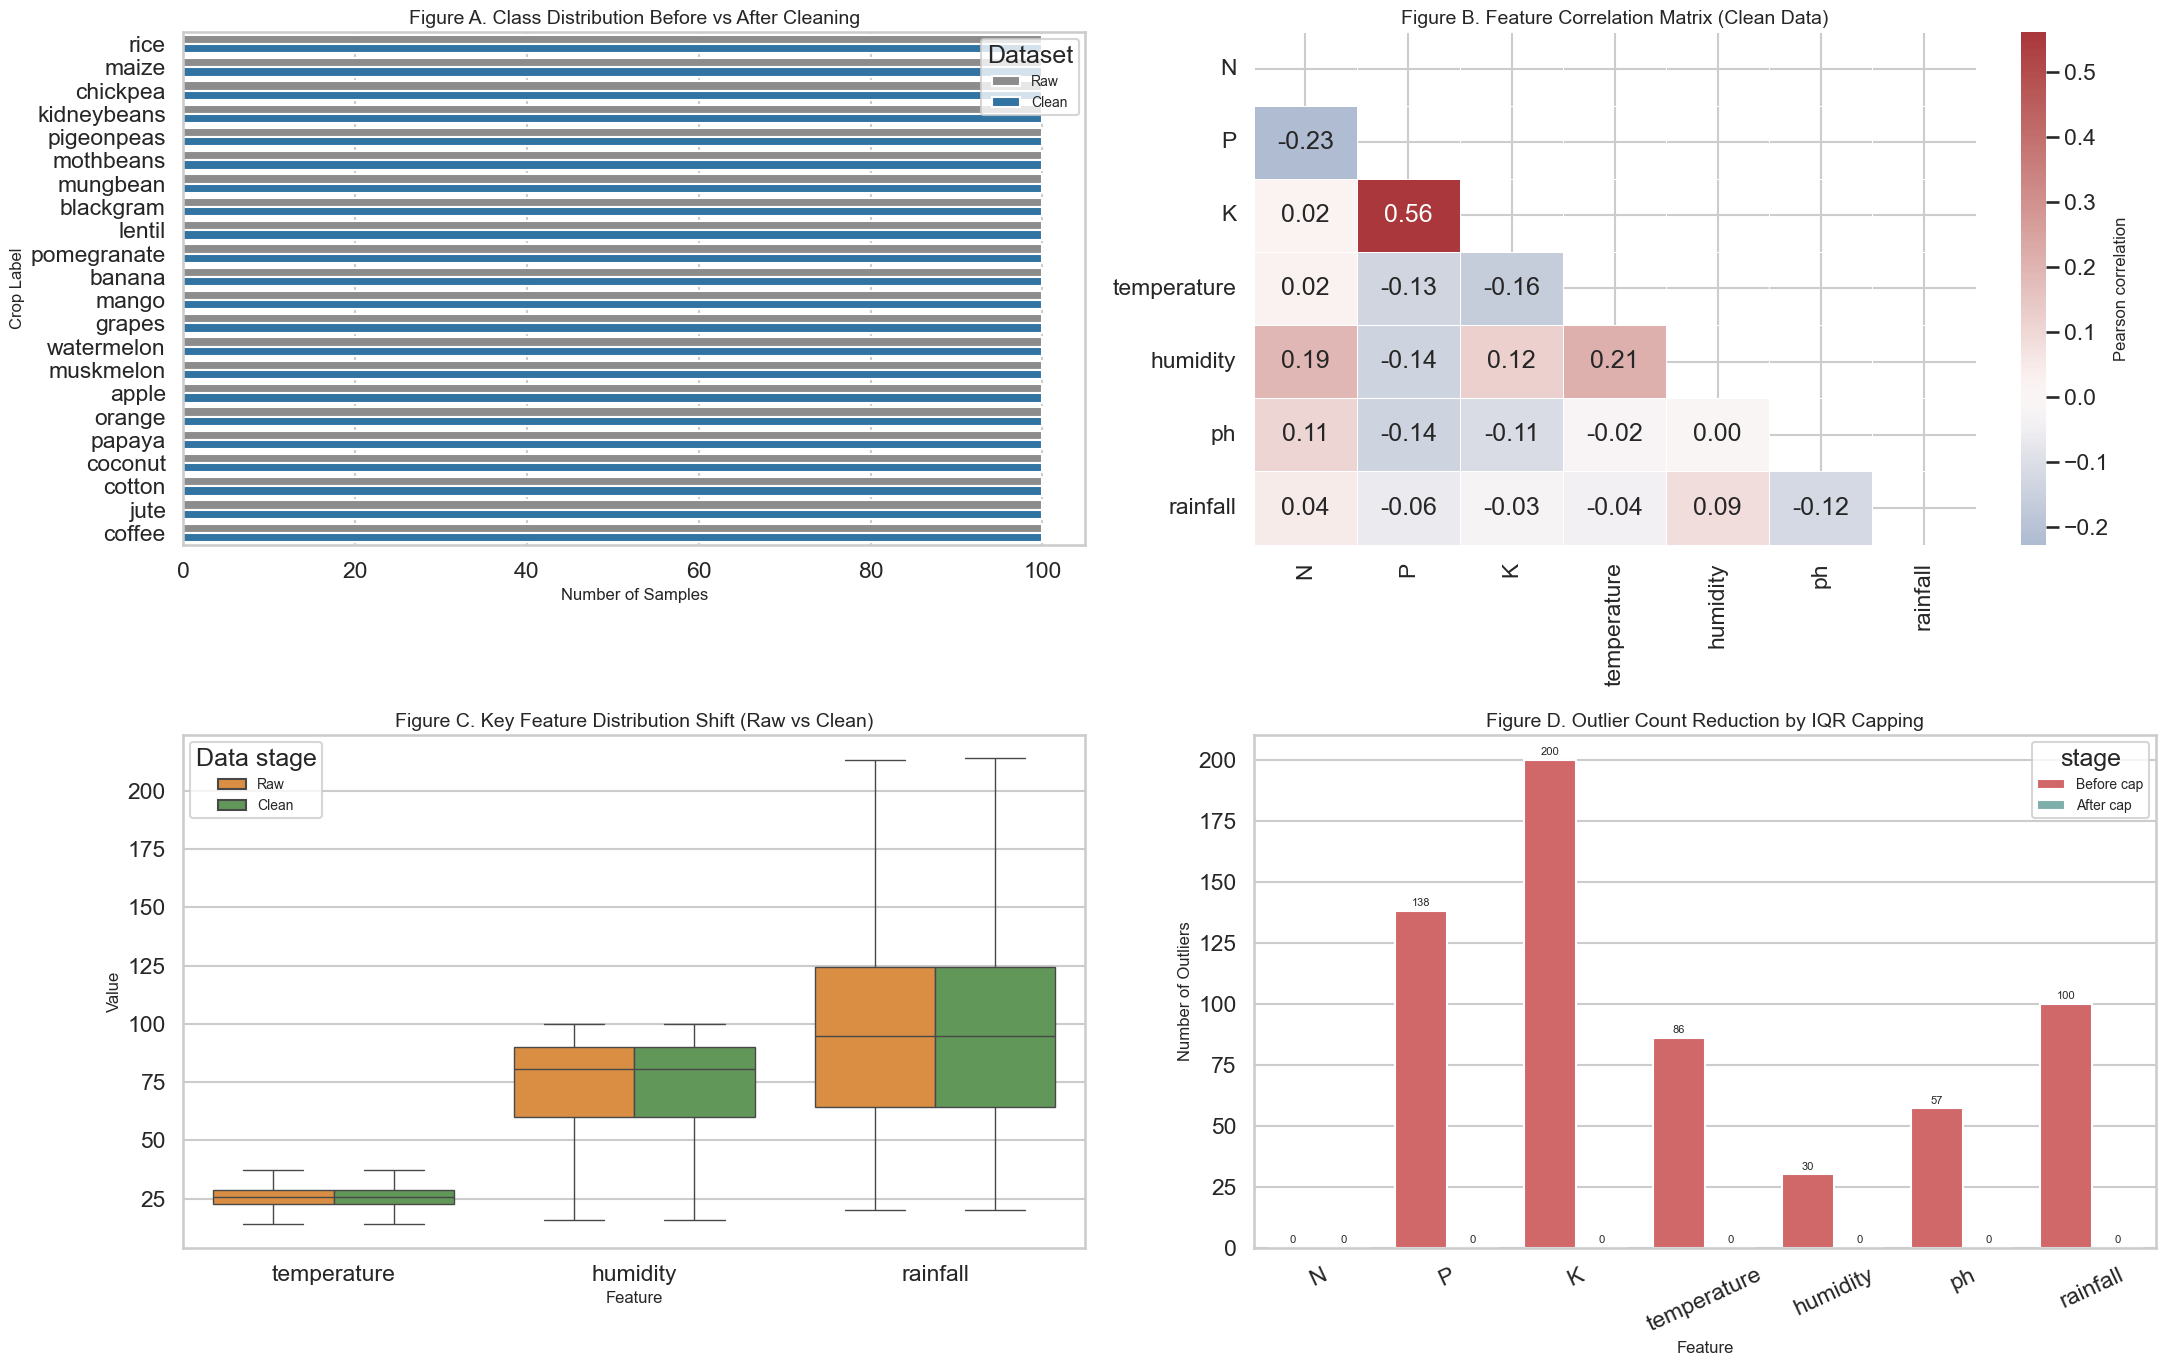

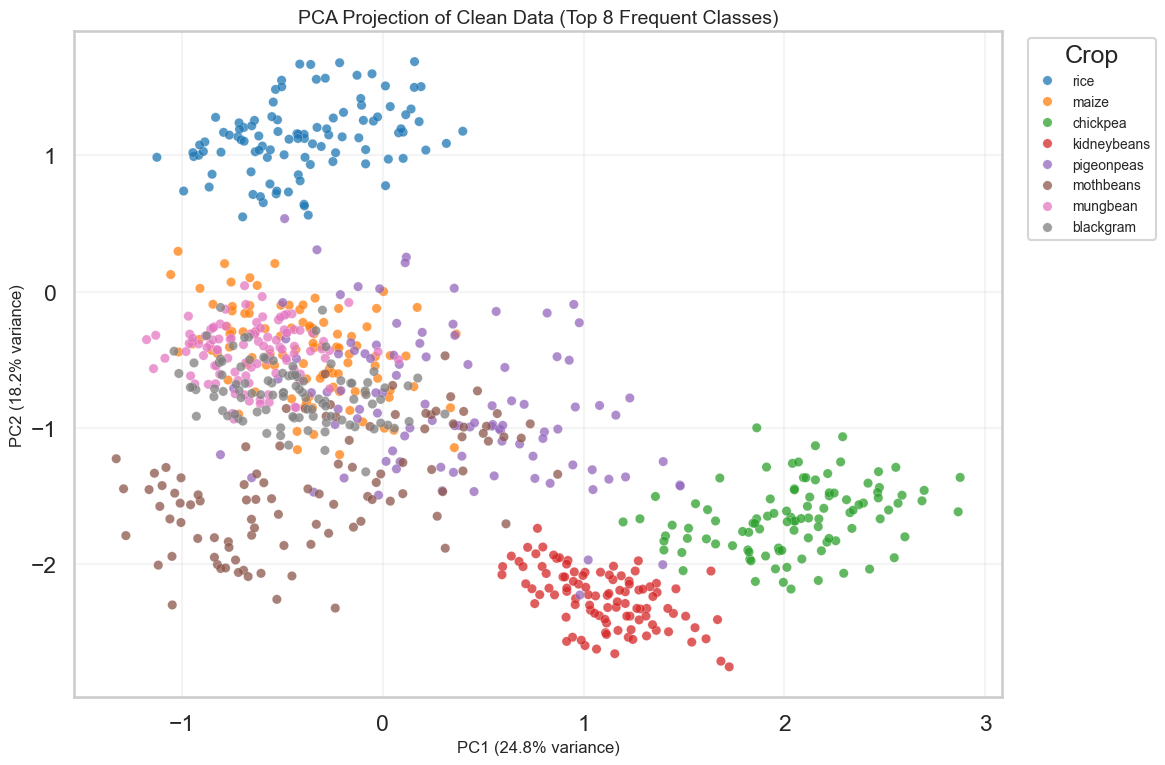

In [6]:
# Publication-style exploratory visualization before training
raw_label_series = raw_df[TARGET_COLUMN].astype(str).str.strip().str.lower()
raw_label_counts = raw_label_series.value_counts()
clean_label_counts = clean_df[TARGET_COLUMN].value_counts()

class_compare_df = (
    pd.DataFrame({"Raw": raw_label_counts, "Clean": clean_label_counts})
    .fillna(0)
    .astype(int)
    .sort_values("Clean", ascending=True)
    .reset_index()
    .rename(columns={"index": "label"})
)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# Figure A: class distribution before/after cleaning
class_melt_df = class_compare_df.melt(
    id_vars="label",
    value_vars=["Raw", "Clean"],
    var_name="dataset",
    value_name="count",
)
sns.barplot(
    data=class_melt_df,
    y="label",
    x="count",
    hue="dataset",
    palette={"Raw": "#8c8c8c", "Clean": "#1f77b4"},
    ax=axes[0, 0],
)
axes[0, 0].set_title("Figure A. Class Distribution Before vs After Cleaning")
axes[0, 0].set_xlabel("Number of Samples")
axes[0, 0].set_ylabel("Crop Label")
axes[0, 0].legend(title="Dataset")

# Figure B: correlation structure
corr = clean_df[FEATURE_COLUMNS].corr()
corr_mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=corr_mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=axes[0, 1],
)
axes[0, 1].set_title("Figure B. Feature Correlation Matrix (Clean Data)")

# Figure C: distribution shift on key agronomic variables
dist_features = ["temperature", "humidity", "rainfall"]
raw_dist_df = raw_df[dist_features].copy()
raw_dist_df["stage"] = "Raw"
clean_dist_df = clean_df[dist_features].copy()
clean_dist_df["stage"] = "Clean"
dist_melt_df = pd.concat([raw_dist_df, clean_dist_df], ignore_index=True).melt(
    id_vars="stage",
    var_name="feature",
    value_name="value",
).dropna()
sns.boxplot(
    data=dist_melt_df,
    x="feature",
    y="value",
    hue="stage",
    showfliers=False,
    palette={"Raw": "#f28e2b", "Clean": "#59a14f"},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Figure C. Key Feature Distribution Shift (Raw vs Clean)")
axes[1, 0].set_xlabel("Feature")
axes[1, 0].set_ylabel("Value")
axes[1, 0].legend(title="Data stage")

# Figure D: outlier capping impact
outlier_plot_df = outlier_stats[["feature", "outliers_before", "outliers_after"]].melt(
    id_vars="feature",
    var_name="stage",
    value_name="count",
)
outlier_plot_df["stage"] = outlier_plot_df["stage"].map(
    {"outliers_before": "Before cap", "outliers_after": "After cap"}
)
sns.barplot(
    data=outlier_plot_df,
    x="feature",
    y="count",
    hue="stage",
    palette={"Before cap": "#e15759", "After cap": "#76b7b2"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Figure D. Outlier Count Reduction by IQR Capping")
axes[1, 1].set_xlabel("Feature")
axes[1, 1].set_ylabel("Number of Outliers")
axes[1, 1].tick_params(axis="x", rotation=25)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt="%d", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Publication-style class separability view with PCA (top frequent classes)
pca_input = StandardScaler().fit_transform(clean_df[FEATURE_COLUMNS])
pca = PCA(n_components=2, random_state=CONFIG.random_seed)
pca_emb = pca.fit_transform(pca_input)

pca_df = pd.DataFrame(
    {
        "PC1": pca_emb[:, 0],
        "PC2": pca_emb[:, 1],
        "label": clean_df[TARGET_COLUMN].values,
    }
)

top_classes = pca_df["label"].value_counts().head(8).index.tolist()
pca_plot_df = pca_df[pca_df["label"].isin(top_classes)].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="label",
    hue_order=top_classes,
    palette="tab10",
    s=45,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.2,
    ax=ax,
)
ax.set_title("PCA Projection of Clean Data (Top 8 Frequent Classes)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5) Cài đặt hàm/lớp lõi

Phần này định nghĩa các hàm chuẩn hóa input, huấn luyện, đánh giá và post-processing để tái sử dụng nhất quán.

In [8]:
def build_model_specs(config: TrainConfig):
    """Trả về 4 mô hình và lưới tham số để tune bằng inner CV."""
    return {
        "RandomForest": {
            "estimator": RandomForestClassifier(random_state=config.random_seed, n_jobs=-1),
            "param_grid": {
                "n_estimators": [200, 400],
                "max_depth": [None, 20],
                "min_samples_split": [2, 4],
                "min_samples_leaf": [1, 2],
            },
        },
        "NaiveBayes": {
            "estimator": GaussianNB(),
            "param_grid": {
                "var_smoothing": [1e-9, 1e-8, 1e-7],
            },
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {
                "n_neighbors": [5, 7, 9],
                "weights": ["uniform", "distance"],
                "metric": ["minkowski"],
            },
        },
        "SVM": {
            "estimator": SVC(probability=True, random_state=config.random_seed),
            "param_grid": {
                "kernel": ["rbf"],
                "C": [1, 10],
                "gamma": ["scale", "auto"],
            },
        },
    }


def split_holdout_data(df: pd.DataFrame):
    """Tách test hold-out 20%, phần còn lại dùng cho nested CV."""
    X = df[FEATURE_COLUMNS].copy()
    y = df["crop_id"].copy()

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X,
        y,
        test_size=CONFIG.test_size,
        random_state=CONFIG.random_seed,
        stratify=y,
    )

    return X_trainval, X_test, y_trainval, y_test


def scale_train_val_test(X_train, X_val, X_test):
    """Chuẩn hóa MinMax -> Standard theo đúng quy trình production."""
    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()

    X_train_mm = minmax_scaler.fit_transform(X_train)
    X_val_mm = minmax_scaler.transform(X_val)
    X_test_mm = minmax_scaler.transform(X_test)

    X_train_scaled = standard_scaler.fit_transform(X_train_mm)
    X_val_scaled = standard_scaler.transform(X_val_mm)
    X_test_scaled = standard_scaler.transform(X_test_mm)

    return X_train_scaled, X_val_scaled, X_test_scaled, minmax_scaler, standard_scaler


def run_nested_cv_for_model(model_name, model_spec, X_trainval, y_trainval):
    """Outer CV để ước lượng validation, inner CV để chọn siêu tham số."""
    outer_cv = StratifiedKFold(n_splits=CONFIG.outer_folds, shuffle=True, random_state=CONFIG.random_seed)
    inner_cv = StratifiedKFold(n_splits=CONFIG.inner_folds, shuffle=True, random_state=CONFIG.random_seed)

    fold_rows = []

    for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_trainval, y_trainval), start=1):
        X_outer_train = X_trainval.iloc[train_idx]
        X_outer_val = X_trainval.iloc[val_idx]
        y_outer_train = y_trainval.iloc[train_idx]
        y_outer_val = y_trainval.iloc[val_idx]

        X_outer_train_scaled, X_outer_val_scaled, _, _, _ = scale_train_val_test(
            X_outer_train,
            X_outer_val,
            X_outer_val,
        )

        search = GridSearchCV(
            estimator=clone(model_spec["estimator"]),
            param_grid=model_spec["param_grid"],
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_outer_train_scaled, y_outer_train)
        best_model = search.best_estimator_

        y_train_pred = best_model.predict(X_outer_train_scaled)
        y_val_pred = best_model.predict(X_outer_val_scaled)

        fold_rows.append({
            "model": model_name,
            "fold": fold_idx,
            "best_params": json.dumps(search.best_params_, ensure_ascii=False),
            "accuracy_train": float(accuracy_score(y_outer_train, y_train_pred)),
            "accuracy_val": float(accuracy_score(y_outer_val, y_val_pred)),
            "precision_macro_val": float(precision_score(y_outer_val, y_val_pred, average="macro", zero_division=0)),
            "recall_macro_val": float(recall_score(y_outer_val, y_val_pred, average="macro", zero_division=0)),
            "f1_macro_val": float(f1_score(y_outer_val, y_val_pred, average="macro", zero_division=0)),
            "inner_best_score_f1": float(search.best_score_),
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "accuracy_train_mean": float(fold_df["accuracy_train"].mean()),
        "accuracy_train_std": float(fold_df["accuracy_train"].std(ddof=0)),
        "accuracy_val_mean": float(fold_df["accuracy_val"].mean()),
        "accuracy_val_std": float(fold_df["accuracy_val"].std(ddof=0)),
        "precision_val_mean": float(fold_df["precision_macro_val"].mean()),
        "recall_val_mean": float(fold_df["recall_macro_val"].mean()),
        "f1_val_mean": float(fold_df["f1_macro_val"].mean()),
    }
    summary["val_balance_score"] = float(
        (summary["precision_val_mean"] + summary["recall_val_mean"] + summary["f1_val_mean"]) / 3
    )

    best_params_global = json.loads(fold_df["best_params"].value_counts().index[0])
    return fold_df, summary, best_params_global


def train_and_test_final_model(model_spec, best_params, X_trainval, y_trainval, X_test, y_test):
    """Train lại trên train/val đầy đủ rồi báo cáo test hold-out 20%."""
    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()

    X_train_mm = minmax_scaler.fit_transform(X_trainval)
    X_train_scaled = standard_scaler.fit_transform(X_train_mm)

    X_test_mm = minmax_scaler.transform(X_test)
    X_test_scaled = standard_scaler.transform(X_test_mm)

    final_model = clone(model_spec["estimator"]).set_params(**best_params)
    t0 = time.perf_counter()
    final_model.fit(X_train_scaled, y_trainval)
    train_time_sec = time.perf_counter() - t0

    y_test_pred = final_model.predict(X_test_scaled)

    return {
        "fitted_model": final_model,
        "train_time_sec": float(train_time_sec),
        "accuracy_test": float(accuracy_score(y_test, y_test_pred)),
        "precision_macro_test": float(precision_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "recall_macro_test": float(recall_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "f1_macro_test": float(f1_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "classification_report": classification_report(y_test, y_test_pred, output_dict=True, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred),
        "minmax_scaler": minmax_scaler,
        "standard_scaler": standard_scaler,
    }

## 6) Huấn luyện + validation theo nested CV, sau đó testing hold-out

### Pha 1: Tách test hold-out
- Giữ cố định 20% dữ liệu cho kiểm thử cuối cùng.

### Pha 2: Nested cross-validation trên 80% còn lại
- Outer CV dùng để ước lượng khách quan hiệu năng validation.
- Inner CV dùng để chọn siêu tham số cho từng mô hình.

### Pha 3: Huấn luyện lại và đánh giá test
- Huấn luyện lại trên toàn bộ train/val với siêu tham số đã chọn.
- Chỉ dùng tập test để báo cáo cuối, không dùng để tune.

In [9]:
# Kiểm tra nhanh pipeline nested CV trên tập mẫu nhỏ
quick_df = clean_df.sample(min(300, len(clean_df)), random_state=CONFIG.random_seed)
quick_X_trainval, quick_X_test, quick_y_trainval, quick_y_test = split_holdout_data(quick_df)
quick_specs = build_model_specs(CONFIG)

quick_fold_df, quick_summary, quick_best_params = run_nested_cv_for_model(
    "RandomForest",
    quick_specs["RandomForest"],
    quick_X_trainval,
    quick_y_trainval,
)
quick_test = train_and_test_final_model(
    quick_specs["RandomForest"],
    quick_best_params,
    quick_X_trainval,
    quick_y_trainval,
    quick_X_test,
    quick_y_test,
)

print(f"Validation accuracy mean (quick): {quick_summary['accuracy_val_mean']:.4f}")
print(f"Test accuracy (quick): {quick_test['accuracy_test']:.4f}")

KeyboardInterrupt: 

In [10]:
# Nested CV + hold-out test 20%
X_trainval, X_test, y_trainval, y_test = split_holdout_data(clean_df)
model_specs = build_model_specs(CONFIG)

history = []
nested_fold_metrics = []
test_artifacts = {}

for model_name, model_spec in model_specs.items():
    print(f"Đang chạy nested CV cho {model_name} ...")
    fold_df, val_summary, best_params = run_nested_cv_for_model(
        model_name,
        model_spec,
        X_trainval,
        y_trainval,
    )
    nested_fold_metrics.append(fold_df)

    test_result = train_and_test_final_model(
        model_spec,
        best_params,
        X_trainval,
        y_trainval,
        X_test,
        y_test,
    )
    test_artifacts[model_name] = {
        **test_result,
        "best_params": best_params,
    }

    history.append({
        "model": model_name,
        "best_params": json.dumps(best_params, ensure_ascii=False),
        "train_time_sec": test_result["train_time_sec"],
        "accuracy_train_mean": val_summary["accuracy_train_mean"],
        "accuracy_train_std": val_summary["accuracy_train_std"],
        "accuracy_val_mean": val_summary["accuracy_val_mean"],
        "accuracy_val_std": val_summary["accuracy_val_std"],
        "precision_val_mean": val_summary["precision_val_mean"],
        "recall_val_mean": val_summary["recall_val_mean"],
        "f1_val_mean": val_summary["f1_val_mean"],
        "val_balance_score": val_summary["val_balance_score"],
        "accuracy_test": test_result["accuracy_test"],
        "precision_test": test_result["precision_macro_test"],
        "recall_test": test_result["recall_macro_test"],
        "f1_test": test_result["f1_macro_test"],
        "generalization_gap": val_summary["accuracy_train_mean"] - val_summary["accuracy_val_mean"],
    })

nested_fold_metrics_df = pd.concat(nested_fold_metrics, ignore_index=True)
history_df = pd.DataFrame(history).sort_values(by=["val_balance_score", "accuracy_test"], ascending=False).reset_index(drop=True)

display(nested_fold_metrics_df.head(20))

best_model_name = history_df.iloc[0]["model"]
best_result = test_artifacts[best_model_name]
best_model = best_result["fitted_model"]

# Scaler của mô hình tốt nhất để tương thích phần export/smoke test.
bundle = {
    "X_train": X_trainval,
    "X_test": X_test,
    "standard_scaler": best_result["standard_scaler"],
    "minmax_scaler": best_result["minmax_scaler"],
}

print(f"Mô hình được chọn theo validation cân bằng: {best_model_name}")
print(
    f"Validation balance={history_df.iloc[0]['val_balance_score']:.4f} | "
    f"Test F1={history_df.iloc[0]['f1_test']:.4f}"
)

Đang chạy nested CV cho RandomForest ...
Đang chạy nested CV cho NaiveBayes ...
Đang chạy nested CV cho KNN ...
Đang chạy nested CV cho SVM ...


,model,fold,best_params,accuracy_train,accuracy_val,precision_macro_val,recall_macro_val,f1_macro_val,inner_best_score_f1
0,RandomForest,1,"{""max_depth"": null, ""min_samples_leaf"": 1, ""mi...",1.000000,0.991477,0.991979,0.991477,0.991469,0.996445
1,RandomForest,2,"{""max_depth"": null, ""min_samples_leaf"": 1, ""mi...",1.000000,0.997159,0.997326,0.997159,0.997156,0.990727
2,RandomForest,3,"{""max_depth"": null, ""min_samples_leaf"": 1, ""mi...",1.000000,0.994318,0.994318,0.994318,0.994318,0.994977
3,RandomForest,4,"{""max_depth"": null, ""min_samples_leaf"": 2, ""mi...",0.999290,0.991477,0.992823,0.991477,0.991402,0.995749
4,RandomForest,5,"{""max_depth"": null, ""min_samples_leaf"": 1, ""mi...",1.000000,0.997159,0.997326,0.997159,0.997156,0.992155
5,NaiveBayes,1,"{""var_smoothing"": 1e-09}",0.995739,0.994318,0.994949,0.994318,0.994296,0.993591
6,NaiveBayes,2,"{""var_smoothing"": 1e-09}",0.993608,0.997159,0.997326,0.997159,0.997156,0.993589
7,NaiveBayes,3,"{""var_smoothing"": 1e-09}",0.995739,0.994318,0.994318,0.994318,0.994318,0.994289
8,NaiveBayes,4,"{""var_smoothing"": 1e-09}",0.995028,0.994318,0.994949,0.994318,0.994296,0.995028
9,NaiveBayes,5,"{""var_smoothing"": 1e-09}",0.994318,0.994318,0.994318,0.994318,0.994318,0.992161


Mô hình được chọn theo validation cân bằng: NaiveBayes
Validation balance=0.9950 | Test F1=0.9932


In [9]:
with pd.option_context("display.max_colwidth", None):
    display(history_df)

,model,best_params,train_time_sec,accuracy_train_mean,accuracy_train_std,accuracy_val_mean,accuracy_val_std,precision_val_mean,recall_val_mean,f1_val_mean,val_balance_score,accuracy_test,precision_test,recall_test,f1_test,generalization_gap
0,NaiveBayes,"{""var_smoothing"": 1e-09}",0.001497,0.994886,0.000828,0.994886,0.001136,0.995172,0.994886,0.994877,0.994979,0.993182,0.993279,0.993182,0.993178,0.000000
1,RandomForest,"{""max_depth"": null, ""min_samples_leaf"": 1, ""min_samples_split"": 2, ""n_estimators"": 400}",0.625689,0.999858,0.000284,0.994318,0.002541,0.994754,0.994318,0.994300,0.994458,0.995455,0.995671,0.995455,0.995452,0.005540
2,SVM,"{""C"": 10, ""gamma"": ""scale"", ""kernel"": ""rbf""}",0.154806,0.993892,0.000348,0.988636,0.006478,0.989463,0.988636,0.988660,0.988920,0.986364,0.986785,0.986364,0.986355,0.005256
3,KNN,"{""metric"": ""minkowski"", ""n_neighbors"": 5, ""weights"": ""distance""}",0.001485,0.998011,0.003977,0.980682,0.005509,0.982576,0.980682,0.980724,0.981327,0.984091,0.984621,0.984091,0.984020,0.017330


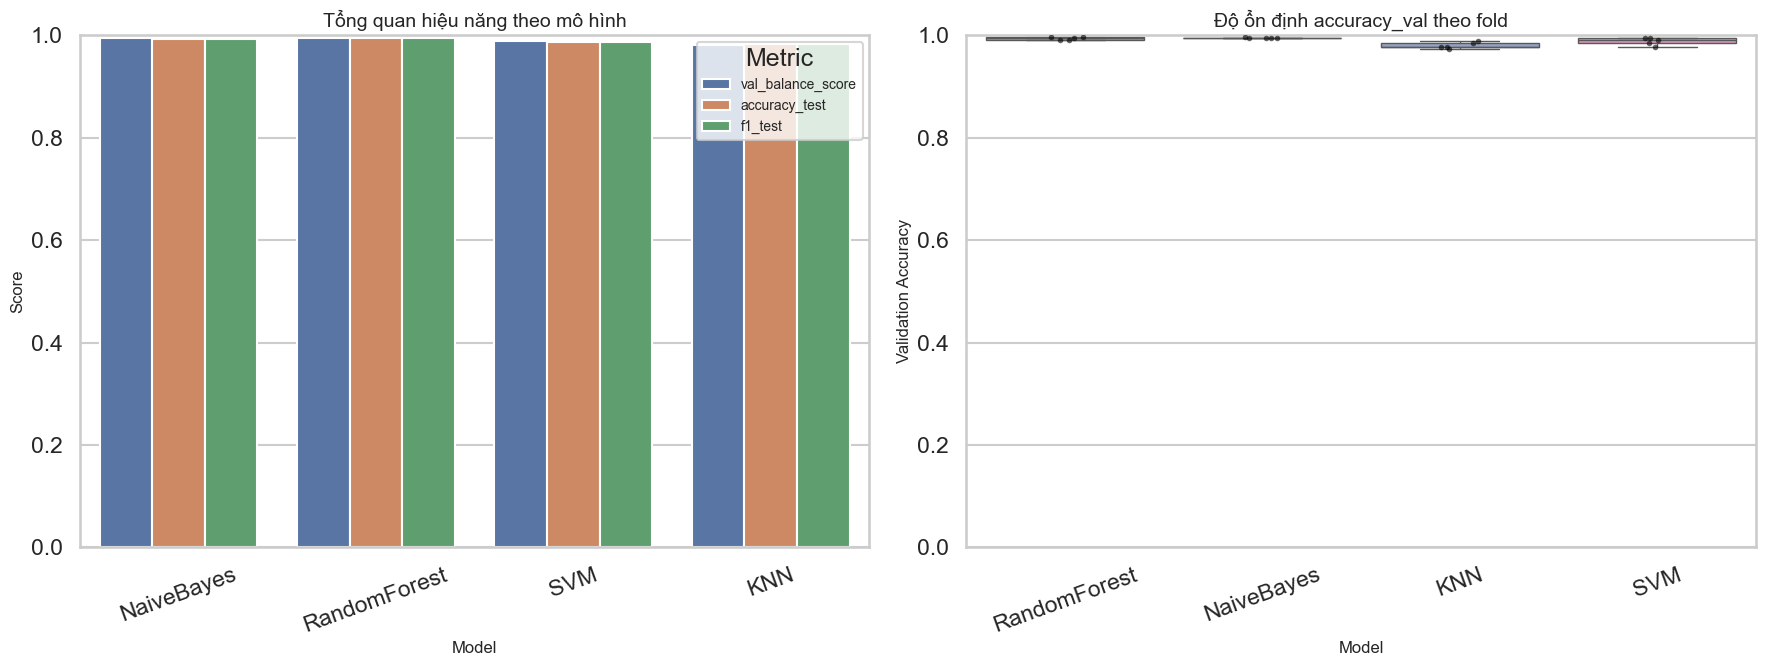

In [10]:
# Visualize nhanh: tổng quan hiệu năng và độ ổn định theo fold
summary_cols = ["model", "val_balance_score", "accuracy_test", "f1_test"]
summary_melt = history_df[summary_cols].melt(
    id_vars="model",
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=summary_melt,
    x="model",
    y="score",
    hue="metric",
    ax=axes[0],
)
axes[0].set_title("Tổng quan hiệu năng theo mô hình")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Metric")

sns.boxplot(
    data=nested_fold_metrics_df,
    x="model",
    y="accuracy_val",
    palette="Set2",
    showfliers=False,
    ax=axes[1],
)
sns.stripplot(
    data=nested_fold_metrics_df,
    x="model",
    y="accuracy_val",
    color="black",
    size=4,
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("Độ ổn định accuracy_val theo fold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 7) Đánh giá validation/testing và phân tích trade-off

Mục tiêu đánh giá đa chiều, tách rõ vai trò validation và testing:
- Validation: `accuracy_train`, `accuracy_val`, precision/recall/F1 để chọn mô hình.
- Testing hold-out 20%: báo cáo khách quan cuối cùng.
- Phân tích trade-off giữa precision và recall (kèm F1) ở cả validation và test.
- Theo dõi khoảng cách `accuracy_train - accuracy_val` để phát hiện overfitting.

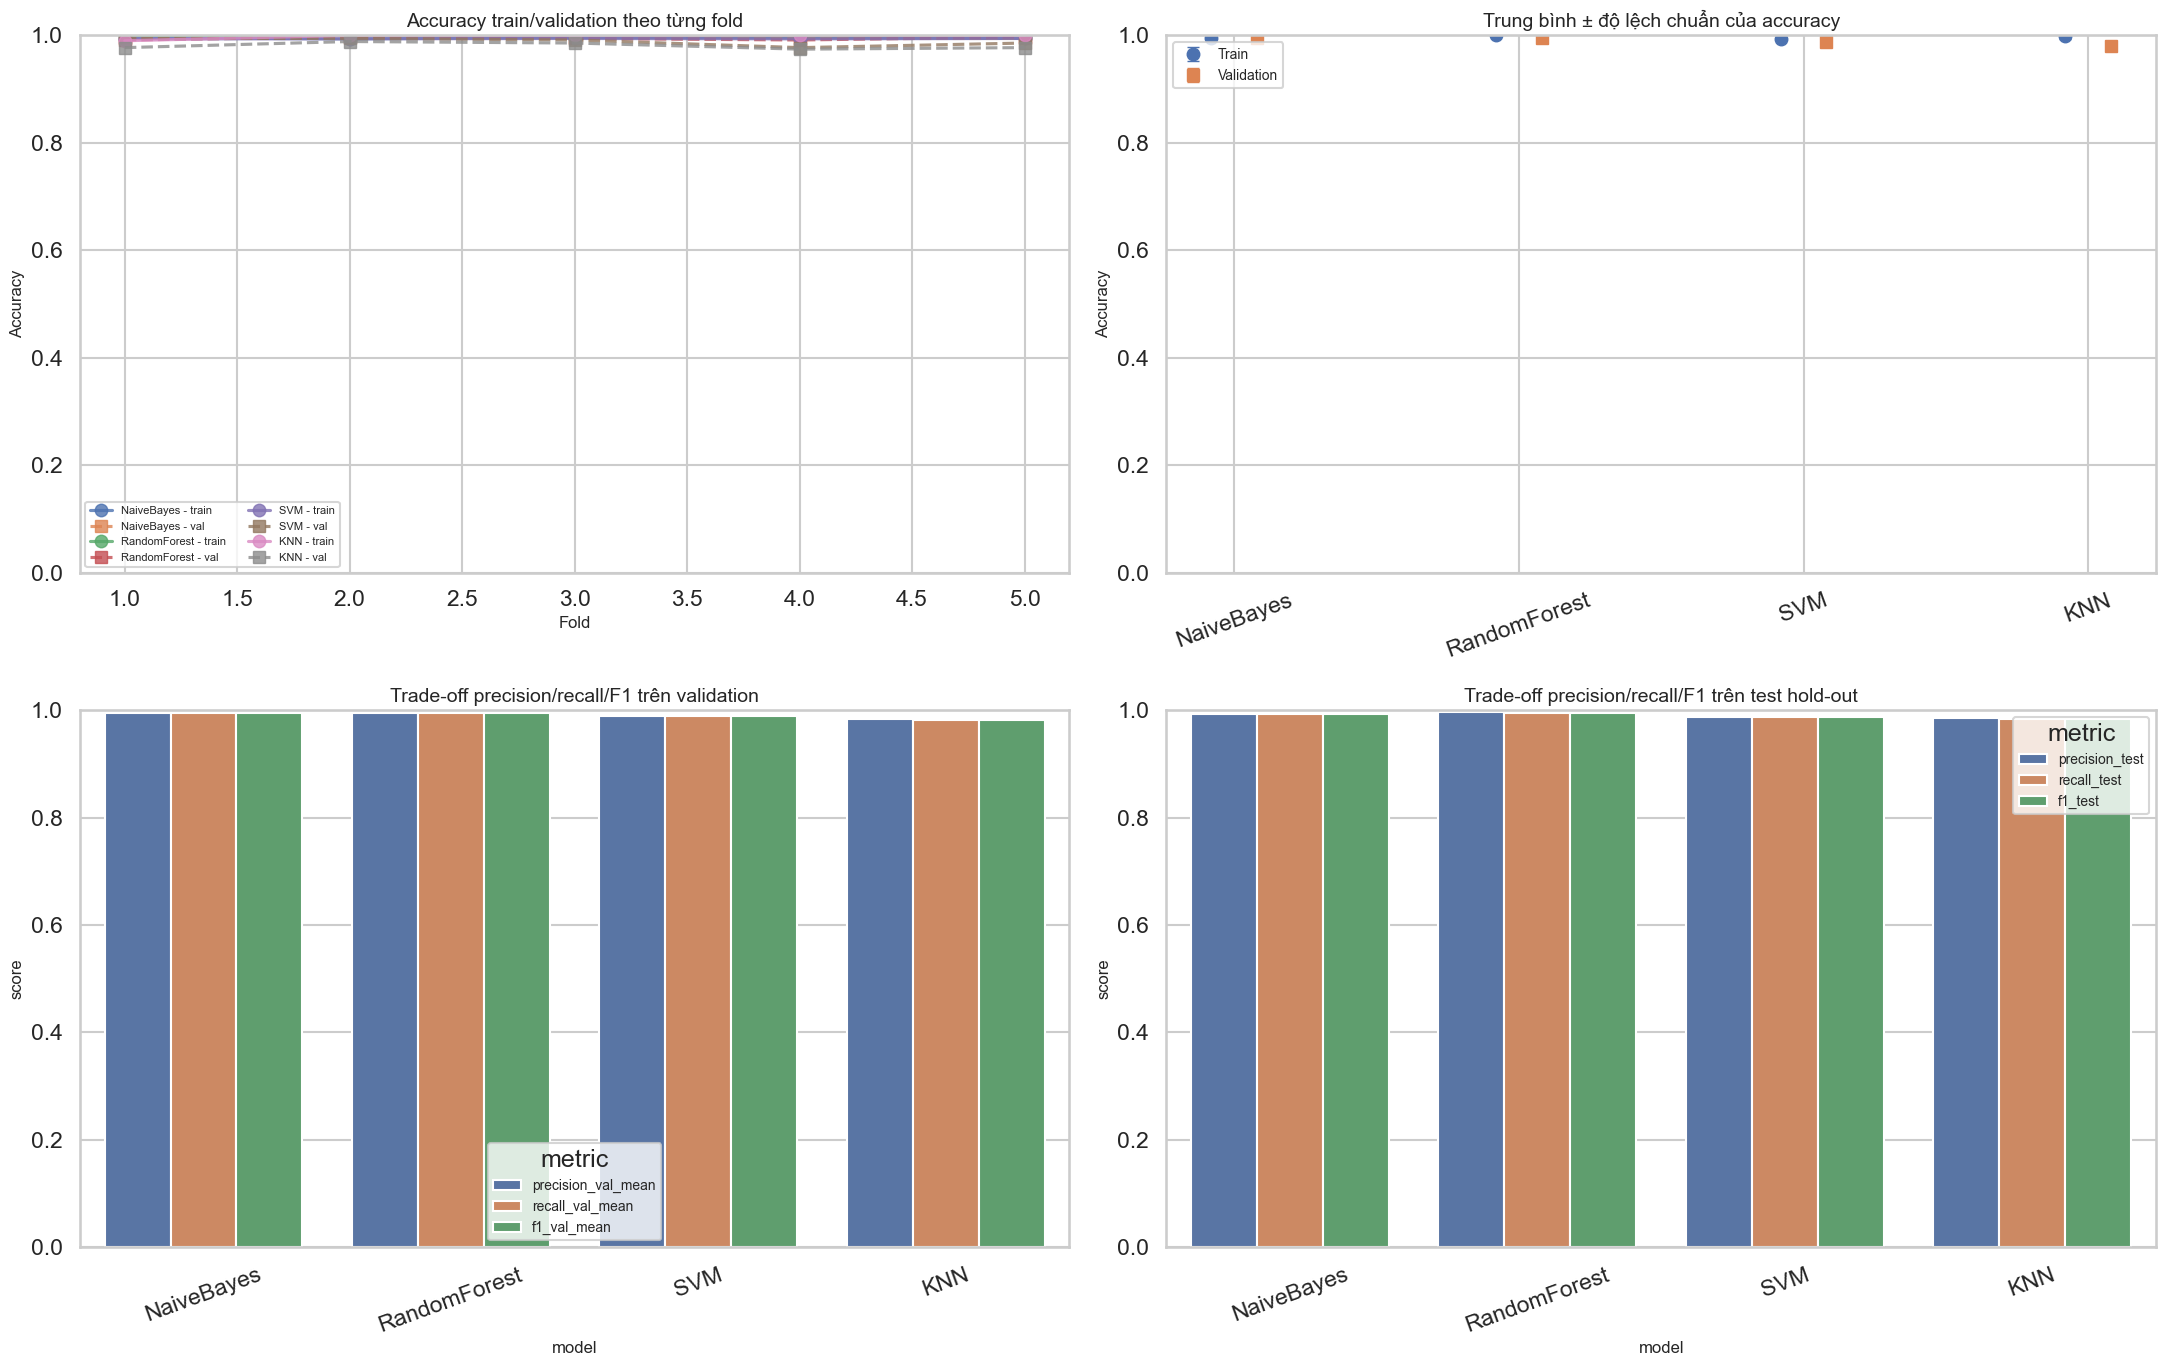

,model,accuracy_train_mean,accuracy_val_mean,generalization_gap,precision_val_mean,recall_val_mean,f1_val_mean,precision_test,recall_test,f1_test,val_balance_score
0,NaiveBayes,0.9949,0.9949,0.0000,0.9952,0.9949,0.9949,0.9933,0.9932,0.9932,0.9950
1,RandomForest,0.9999,0.9943,0.0055,0.9948,0.9943,0.9943,0.9957,0.9955,0.9955,0.9945
2,SVM,0.9939,0.9886,0.0053,0.9895,0.9886,0.9887,0.9868,0.9864,0.9864,0.9889
3,KNN,0.9980,0.9807,0.0173,0.9826,0.9807,0.9807,0.9846,0.9841,0.9840,0.9813


In [17]:
# Dashboard chính: accuracy_train vs accuracy_val + trade-off precision/recall/F1
plot_df = history_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# 1) Đường cong accuracy_train và accuracy_val theo fold cho từng mô hình
for model_name in plot_df["model"].tolist():
    one = nested_fold_metrics_df[nested_fold_metrics_df["model"] == model_name].sort_values("fold")
    axes[0, 0].plot(one["fold"], one["accuracy_train"], marker="o", alpha=0.8, label=f"{model_name} - train")
    axes[0, 0].plot(one["fold"], one["accuracy_val"], marker="s", linestyle="--", alpha=0.8, label=f"{model_name} - val")
axes[0, 0].set_title("Accuracy train/validation theo từng fold")
axes[0, 0].set_xlabel("Fold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend(fontsize=8, ncol=2)

# 2) So sánh mean ± std giữa accuracy_train và accuracy_val
x = np.arange(len(plot_df))
axes[0, 1].errorbar(x - 0.08, plot_df["accuracy_train_mean"], yerr=plot_df["accuracy_train_std"], fmt="o", capsize=4, label="Train")
axes[0, 1].errorbar(x + 0.08, plot_df["accuracy_val_mean"], yerr=plot_df["accuracy_val_std"], fmt="s", capsize=4, label="Validation")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(plot_df["model"], rotation=20)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Trung bình ± độ lệch chuẩn của accuracy")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# 3) Trade-off trên validation
val_tradeoff = plot_df[["model", "precision_val_mean", "recall_val_mean", "f1_val_mean"]].melt(
    id_vars="model", var_name="metric", value_name="score"
)
sns.barplot(data=val_tradeoff, x="model", y="score", hue="metric", ax=axes[1, 0])
axes[1, 0].set_title("Trade-off precision/recall/F1 trên validation")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis="x", rotation=20)

# 4) Trade-off trên test
test_tradeoff = plot_df[["model", "precision_test", "recall_test", "f1_test"]].melt(
    id_vars="model", var_name="metric", value_name="score"
)
sns.barplot(data=test_tradeoff, x="model", y="score", hue="metric", ax=axes[1, 1])
axes[1, 1].set_title("Trade-off precision/recall/F1 trên test hold-out")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(plot_df[[
    "model", "accuracy_train_mean", "accuracy_val_mean", "generalization_gap",
    "precision_val_mean", "recall_val_mean", "f1_val_mean",
    "precision_test", "recall_test", "f1_test", "val_balance_score"
]].round(4))

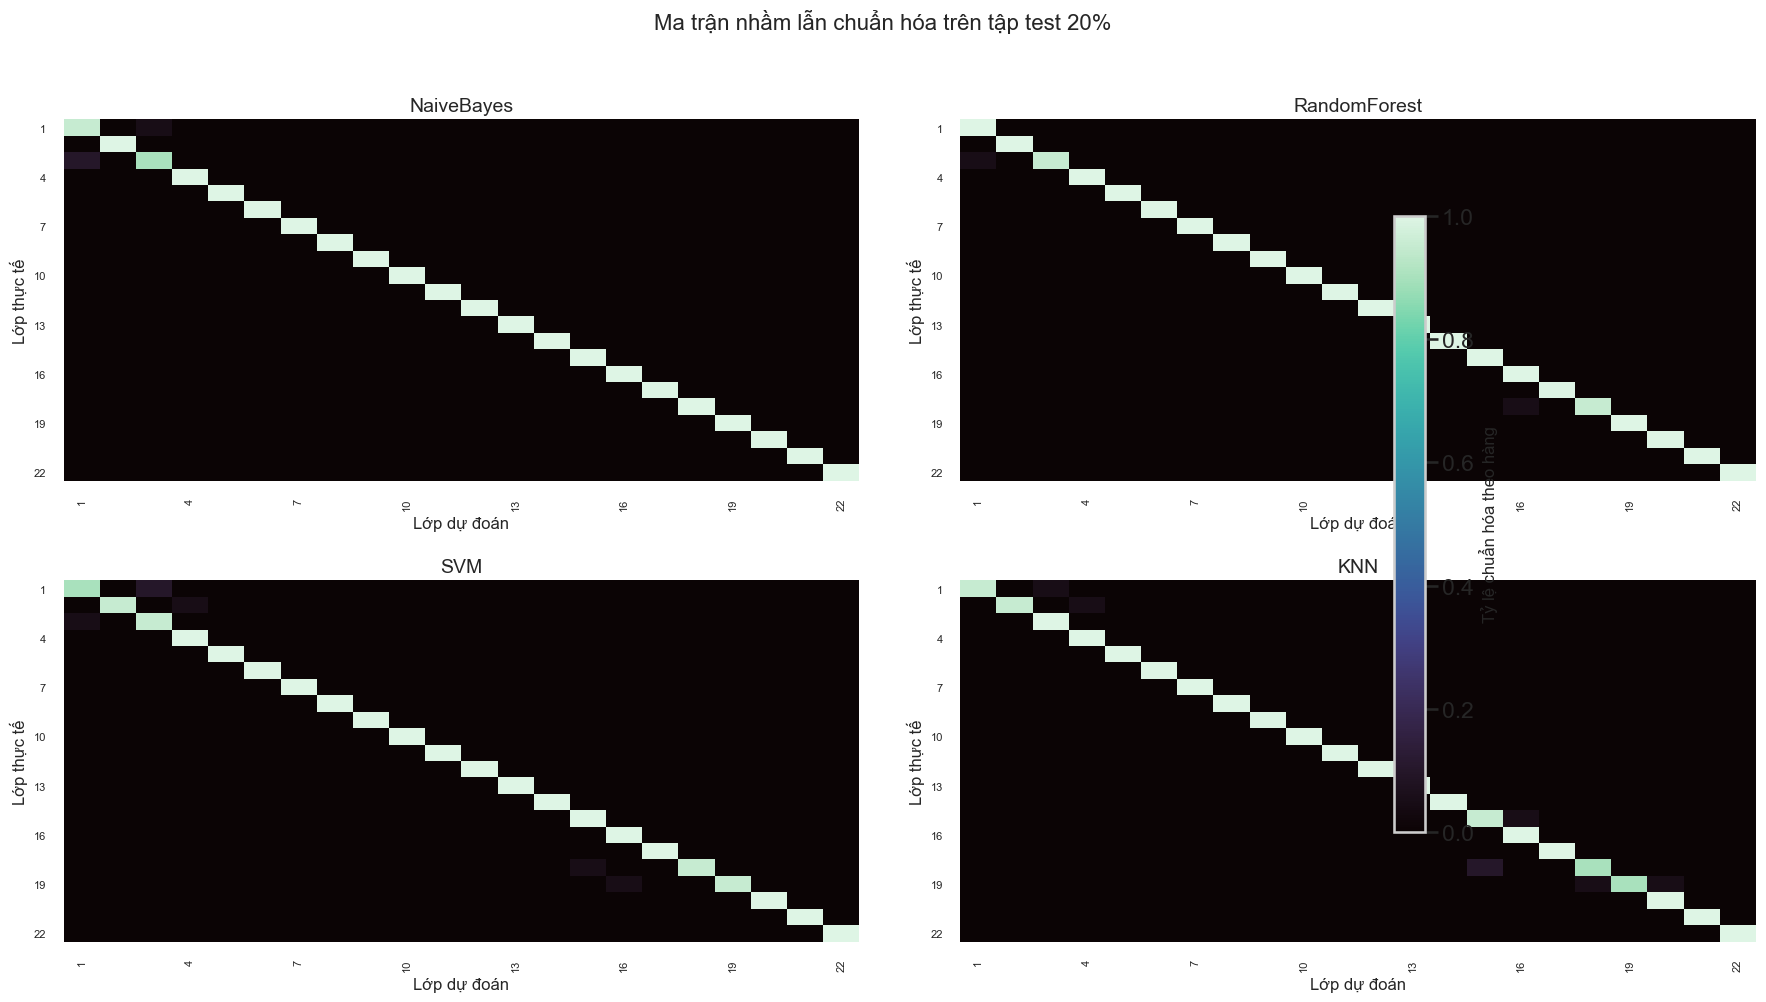

In [18]:
# Ma trận nhầm lẫn chuẩn hóa theo từng mô hình (trên test hold-out)
labels_sorted = sorted(clean_df["crop_id"].unique())
model_list = history_df["model"].tolist()

n_models = len(model_list)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).reshape(-1)

tick_step = 3
tick_idx = np.arange(0, len(labels_sorted), tick_step)
tick_labels = np.array(labels_sorted)[tick_idx]

first_mappable = None
for idx, model_name in enumerate(model_list):
    ax = axes[idx]
    cm = test_artifacts[model_name]["confusion_matrix"].astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    hm = sns.heatmap(
        cm_norm,
        cmap="mako",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        ax=ax,
    )
    if first_mappable is None:
        first_mappable = hm.collections[0]

    ax.set_title(model_name)
    ax.set_xlabel("Lớp dự đoán")
    ax.set_ylabel("Lớp thực tế")
    ax.set_xticks(tick_idx + 0.5)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax.set_yticks(tick_idx + 0.5)
    ax.set_yticklabels(tick_labels, rotation=0, fontsize=8)

for idx in range(n_models, len(axes)):
    axes[idx].axis("off")

if first_mappable is not None:
    cbar = fig.colorbar(first_mappable, ax=axes[:n_models], shrink=0.8, pad=0.01)
    cbar.set_label("Tỷ lệ chuẩn hóa theo hàng")

fig.suptitle("Ma trận nhầm lẫn chuẩn hóa trên tập test 20%", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
comparison_df = history_df[[
    "model",
    "accuracy_train_mean",
    "accuracy_val_mean",
    "accuracy_test",
    "precision_val_mean",
    "recall_val_mean",
    "f1_val_mean",
    "precision_test",
    "recall_test",
    "f1_test",
    "generalization_gap",
    "train_time_sec",
]].copy()

comparison_df.insert(0, "rank", np.arange(1, len(comparison_df) + 1))
comparison_df.columns = [
    "Rank", "Model", "Acc_Train_Mean", "Acc_Val_Mean", "Acc_Test",
    "Precision_Val", "Recall_Val", "F1_Val",
    "Precision_Test", "Recall_Test", "F1_Test",
    "Generalization_Gap", "Train_Time_s",
]

display(comparison_df.round(4))

,Rank,Model,Acc_Train_Mean,Acc_Val_Mean,Acc_Test,Precision_Val,Recall_Val,F1_Val,Precision_Test,Recall_Test,F1_Test,Generalization_Gap,Train_Time_s
0,1,NaiveBayes,0.9949,0.9949,0.9932,0.9952,0.9949,0.9949,0.9933,0.9932,0.9932,0.0000,0.0017
1,2,RandomForest,0.9999,0.9943,0.9955,0.9948,0.9943,0.9943,0.9957,0.9955,0.9955,0.0055,0.5640
2,3,SVM,0.9939,0.9886,0.9864,0.9895,0.9886,0.9887,0.9868,0.9864,0.9864,0.0053,0.1672
3,4,KNN,0.9980,0.9807,0.9841,0.9826,0.9807,0.9807,0.9846,0.9841,0.9840,0.0173,0.0016


In [20]:
# Bảng chênh lệch trade-off giữa validation và test
tradeoff_df = history_df[[
    "model", "precision_val_mean", "recall_val_mean", "f1_val_mean",
    "precision_test", "recall_test", "f1_test", "accuracy_test"
]].copy()

tradeoff_df["delta_precision_recall_val"] = tradeoff_df["precision_val_mean"] - tradeoff_df["recall_val_mean"]
tradeoff_df["delta_precision_recall_test"] = tradeoff_df["precision_test"] - tradeoff_df["recall_test"]
tradeoff_df["delta_f1_accuracy_test"] = tradeoff_df["f1_test"] - tradeoff_df["accuracy_test"]

display(tradeoff_df.round(4))

print("=" * 110)
print(f"Phân tích chi tiết theo lớp cho mô hình tốt nhất: {best_model_name}")
best_report_df = pd.DataFrame(test_artifacts[best_model_name]["classification_report"]).T
best_class_df = best_report_df[best_report_df.index.str.isdigit()].copy()
best_class_df.index = best_class_df.index.astype(int)
best_class_df["crop_name"] = best_class_df.index.map(lambda cid: ID_TO_CROP.get(cid, "unknown"))
best_class_df = best_class_df[["crop_name", "precision", "recall", "f1-score", "support"]]

print("\n10 lớp có F1 thấp nhất:")
display(best_class_df.sort_values("f1-score", ascending=True).head(10).round(4))

print("10 lớp có F1 cao nhất:")
display(best_class_df.sort_values("f1-score", ascending=False).head(10).round(4))

,model,precision_val_mean,recall_val_mean,f1_val_mean,precision_test,recall_test,f1_test,accuracy_test,delta_precision_recall_val,delta_precision_recall_test,delta_f1_accuracy_test
0,NaiveBayes,0.9952,0.9949,0.9949,0.9933,0.9932,0.9932,0.9932,0.0003,0.0001,-0.0000
1,RandomForest,0.9948,0.9943,0.9943,0.9957,0.9955,0.9955,0.9955,0.0004,0.0002,-0.0000
2,SVM,0.9895,0.9886,0.9887,0.9868,0.9864,0.9864,0.9864,0.0008,0.0004,-0.0000
3,KNN,0.9826,0.9807,0.9807,0.9846,0.9841,0.9840,0.9841,0.0019,0.0005,-0.0001


Phân tích chi tiết theo lớp cho mô hình tốt nhất: NaiveBayes

10 lớp có F1 thấp nhất:


,crop_name,precision,recall,f1-score,support
3,jute,0.9474,0.90,0.9231,20.0
1,rice,0.9048,0.95,0.9268,20.0
2,maize,1.0000,1.00,1.0000,20.0
4,cotton,1.0000,1.00,1.0000,20.0
5,coconut,1.0000,1.00,1.0000,20.0
6,papaya,1.0000,1.00,1.0000,20.0
7,orange,1.0000,1.00,1.0000,20.0
8,apple,1.0000,1.00,1.0000,20.0
9,muskmelon,1.0000,1.00,1.0000,20.0
10,watermelon,1.0000,1.00,1.0000,20.0


10 lớp có F1 cao nhất:


,crop_name,precision,recall,f1-score,support
2,maize,1.0,1.0,1.0,20.0
4,cotton,1.0,1.0,1.0,20.0
6,papaya,1.0,1.0,1.0,20.0
5,coconut,1.0,1.0,1.0,20.0
8,apple,1.0,1.0,1.0,20.0
7,orange,1.0,1.0,1.0,20.0
15,lentil,1.0,1.0,1.0,20.0
16,blackgram,1.0,1.0,1.0,20.0
9,muskmelon,1.0,1.0,1.0,20.0
10,watermelon,1.0,1.0,1.0,20.0


In [11]:
# Phân tích trade-off precision/recall trên tập test
tradeoff_test_df = history_df[["model", "precision_test", "recall_test", "f1_test"]].copy()
tradeoff_test_df["delta_precision_recall"] = tradeoff_test_df["precision_test"] - tradeoff_test_df["recall_test"]
tradeoff_test_df["abs_balance_gap"] = tradeoff_test_df["delta_precision_recall"].abs()

best_precision = tradeoff_test_df.loc[tradeoff_test_df["precision_test"].idxmax()]
best_recall = tradeoff_test_df.loc[tradeoff_test_df["recall_test"].idxmax()]
best_f1 = tradeoff_test_df.loc[tradeoff_test_df["f1_test"].idxmax()]
balanced_model = tradeoff_test_df.loc[tradeoff_test_df["abs_balance_gap"].idxmin()]

print("Nhận xét nhanh về trade-off trên tập test:")
print(
    f"- Precision cao nhất: {best_precision['model']} "
    f"(precision={best_precision['precision_test']:.4f}, recall={best_precision['recall_test']:.4f})"
)
print(
    f"- Recall cao nhất: {best_recall['model']} "
    f"(recall={best_recall['recall_test']:.4f}, precision={best_recall['precision_test']:.4f})"
)
print(
    f"- F1 cao nhất (cân bằng P/R): {best_f1['model']} "
    f"(f1={best_f1['f1_test']:.4f}, precision={best_f1['precision_test']:.4f}, recall={best_f1['recall_test']:.4f})"
)
print(
    f"- Cân bằng P/R tốt nhất (|P-R| nhỏ): {balanced_model['model']} "
    f"(|P-R|={balanced_model['abs_balance_gap']:.4f})"
)

with pd.option_context("display.max_colwidth", None):
    display(tradeoff_test_df.sort_values("f1_test", ascending=False).round(4))

Nhận xét nhanh về trade-off trên tập test:
- Precision cao nhất: RandomForest (precision=0.9957, recall=0.9955)
- Recall cao nhất: RandomForest (recall=0.9955, precision=0.9957)
- F1 cao nhất (cân bằng P/R): RandomForest (f1=0.9955, precision=0.9957, recall=0.9955)
- Cân bằng P/R tốt nhất (|P-R| nhỏ): NaiveBayes (|P-R|=0.0001)


,model,precision_test,recall_test,f1_test,delta_precision_recall,abs_balance_gap
1,RandomForest,0.9957,0.9955,0.9955,0.0002,0.0002
0,NaiveBayes,0.9933,0.9932,0.9932,0.0001,0.0001
2,SVM,0.9868,0.9864,0.9864,0.0004,0.0004
3,KNN,0.9846,0.9841,0.9840,0.0005,0.0005


### 7.1) Biểu đồ bổ sung cho báo cáo validation/testing

Các biểu đồ dưới đây tập trung vào:
- Độ ổn định train/validation theo fold (nested CV).
- Trade-off precision/recall/F1 trên validation và test.
- Phân tích lỗi theo lớp cho mô hình tốt nhất.

Tất cả hình có thể lưu độ phân giải cao để phục vụ báo cáo.

In [21]:
# Thiết lập thư mục lưu hình chất lượng cao
FIG_DIR = Path(CONFIG.output_root) / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_publication_figure(fig, filename: str):
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Đã lưu hình: {out_path}")


print(f"Thư mục lưu hình: {FIG_DIR.resolve()}")

Thư mục lưu hình: D:\Workspace\GETPOST\NCKH-Refractor\ml\training_outputs\paper_figures


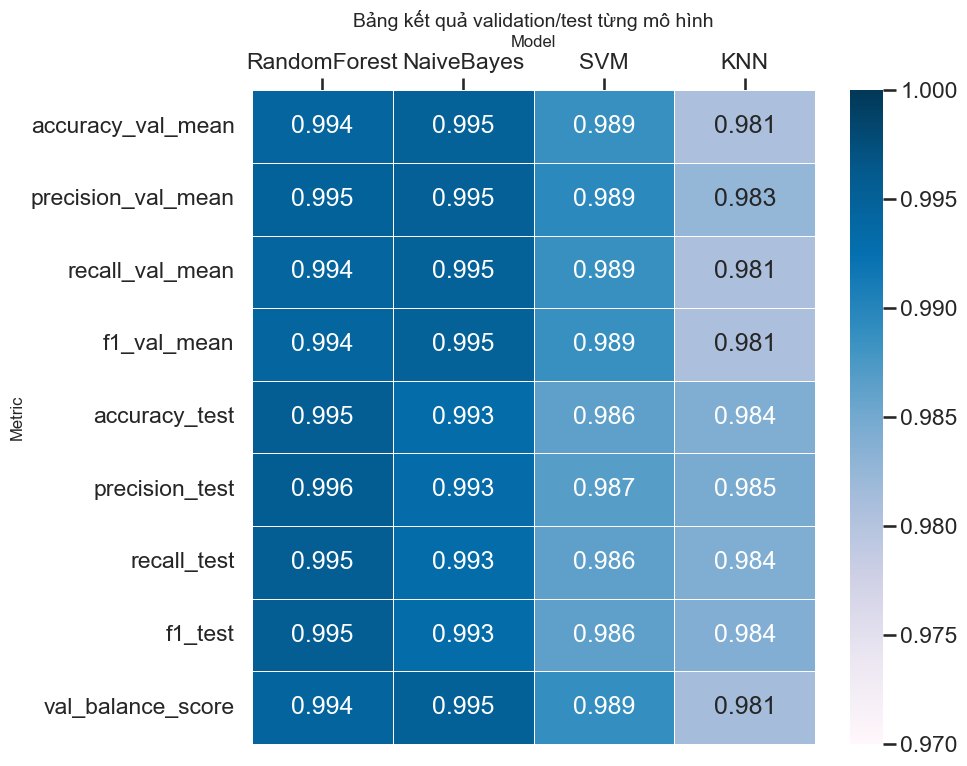

In [27]:
profile_cols = [
    "accuracy_val_mean", "precision_val_mean", "recall_val_mean", "f1_val_mean",
    "accuracy_test", "precision_test", "recall_test", "f1_test", "val_balance_score"
]

profile_df = history_df.set_index("model")[profile_cols].copy()
rf_name = [c for c in profile_df.index if "Random" in c][0]
new_order = [rf_name] + [c for c in profile_df.index if c != rf_name]
profile_df = profile_df.loc[new_order]
annot_values = profile_df.T.applymap(lambda v: f"{v:.3f}")

plt.figure(figsize=(10, 8))  # chỉ 1 figure

sns.heatmap(
    profile_df.T,
    annot=annot_values,
    fmt="",
    cmap="PuBu",
    vmin=0.97, vmax=1.0,
    linewidths=0.6,
)

plt.title("Bảng kết quả validation/test từng mô hình")
plt.xlabel("Model")
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.ylabel("Metric")

plt.tight_layout()
plt.show()

Đã lưu hình: training_outputs\paper_figures\fig02_cv_distribution_and_trajectory.png


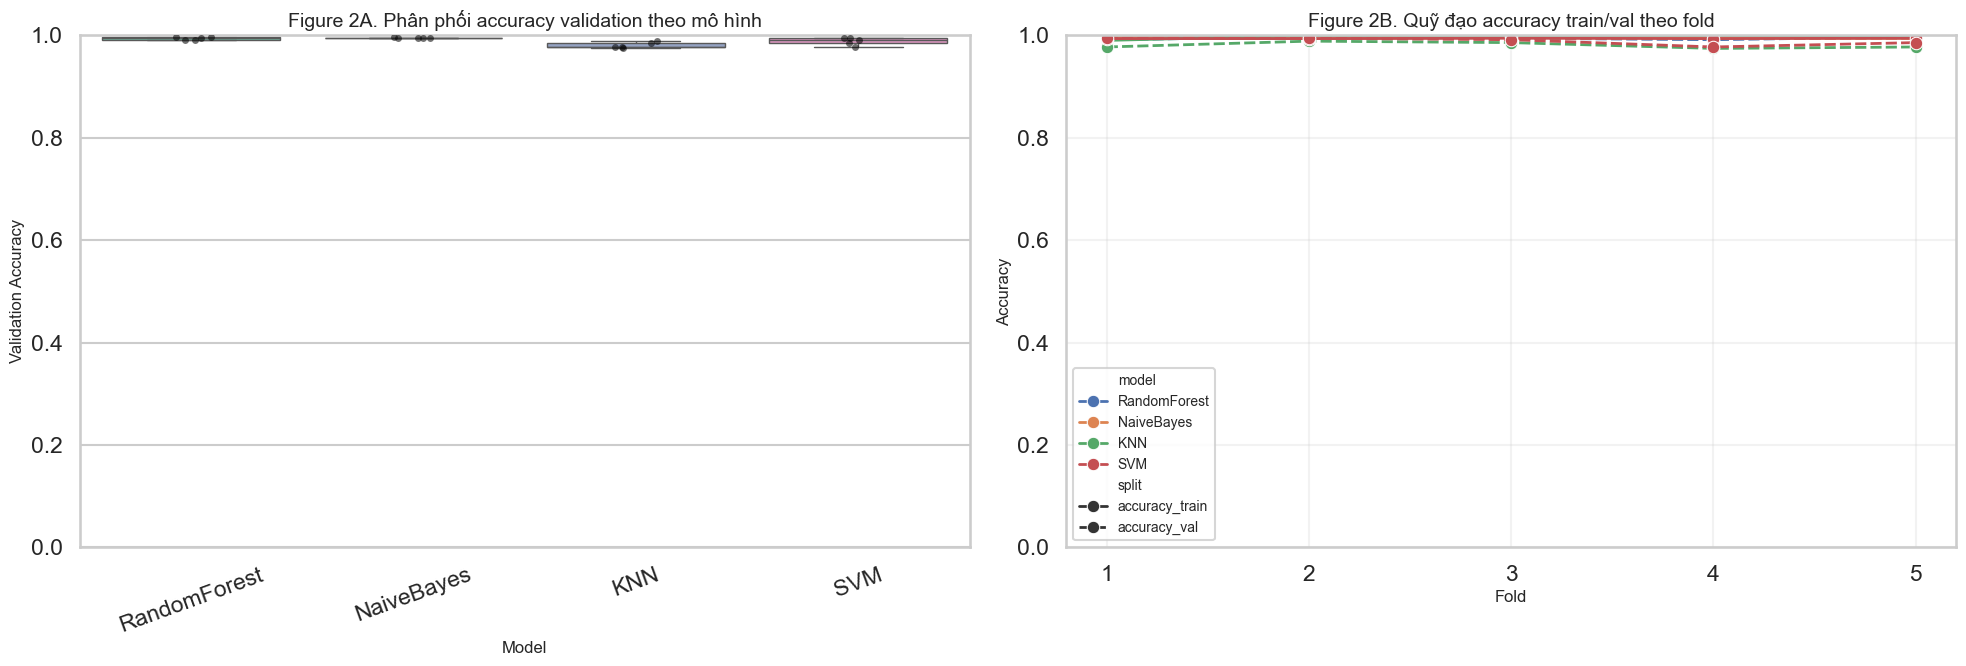

In [23]:
# Figure 2: Phân phối accuracy_train/accuracy_val theo nested CV folds
cv_long_df = nested_fold_metrics_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

val_box = cv_long_df[["model", "accuracy_val"]].rename(columns={"accuracy_val": "accuracy"})
sns.boxplot(
    data=val_box,
    x="model",
    y="accuracy",
    palette="Set2",
    showfliers=False,
    ax=axes[0],
)
sns.stripplot(
    data=val_box,
    x="model",
    y="accuracy",
    color="black",
    size=5,
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Figure 2A. Phân phối accuracy validation theo mô hình")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

line_df = cv_long_df.melt(
    id_vars=["model", "fold"],
    value_vars=["accuracy_train", "accuracy_val"],
    var_name="split",
    value_name="accuracy",
)
sns.lineplot(
    data=line_df,
    x="fold",
    y="accuracy",
    hue="model",
    style="split",
    marker="o",
    linewidth=2,
    ax=axes[1],
)
axes[1].set_title("Figure 2B. Quỹ đạo accuracy train/val theo fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(sorted(cv_long_df["fold"].unique()))
axes[1].grid(alpha=0.25)

plt.tight_layout()
save_publication_figure(fig, "fig02_cv_distribution_and_trajectory.png")
plt.show()

Đã lưu hình: training_outputs\paper_figures\fig03_best_model_confusion_and_low_f1_classes.png


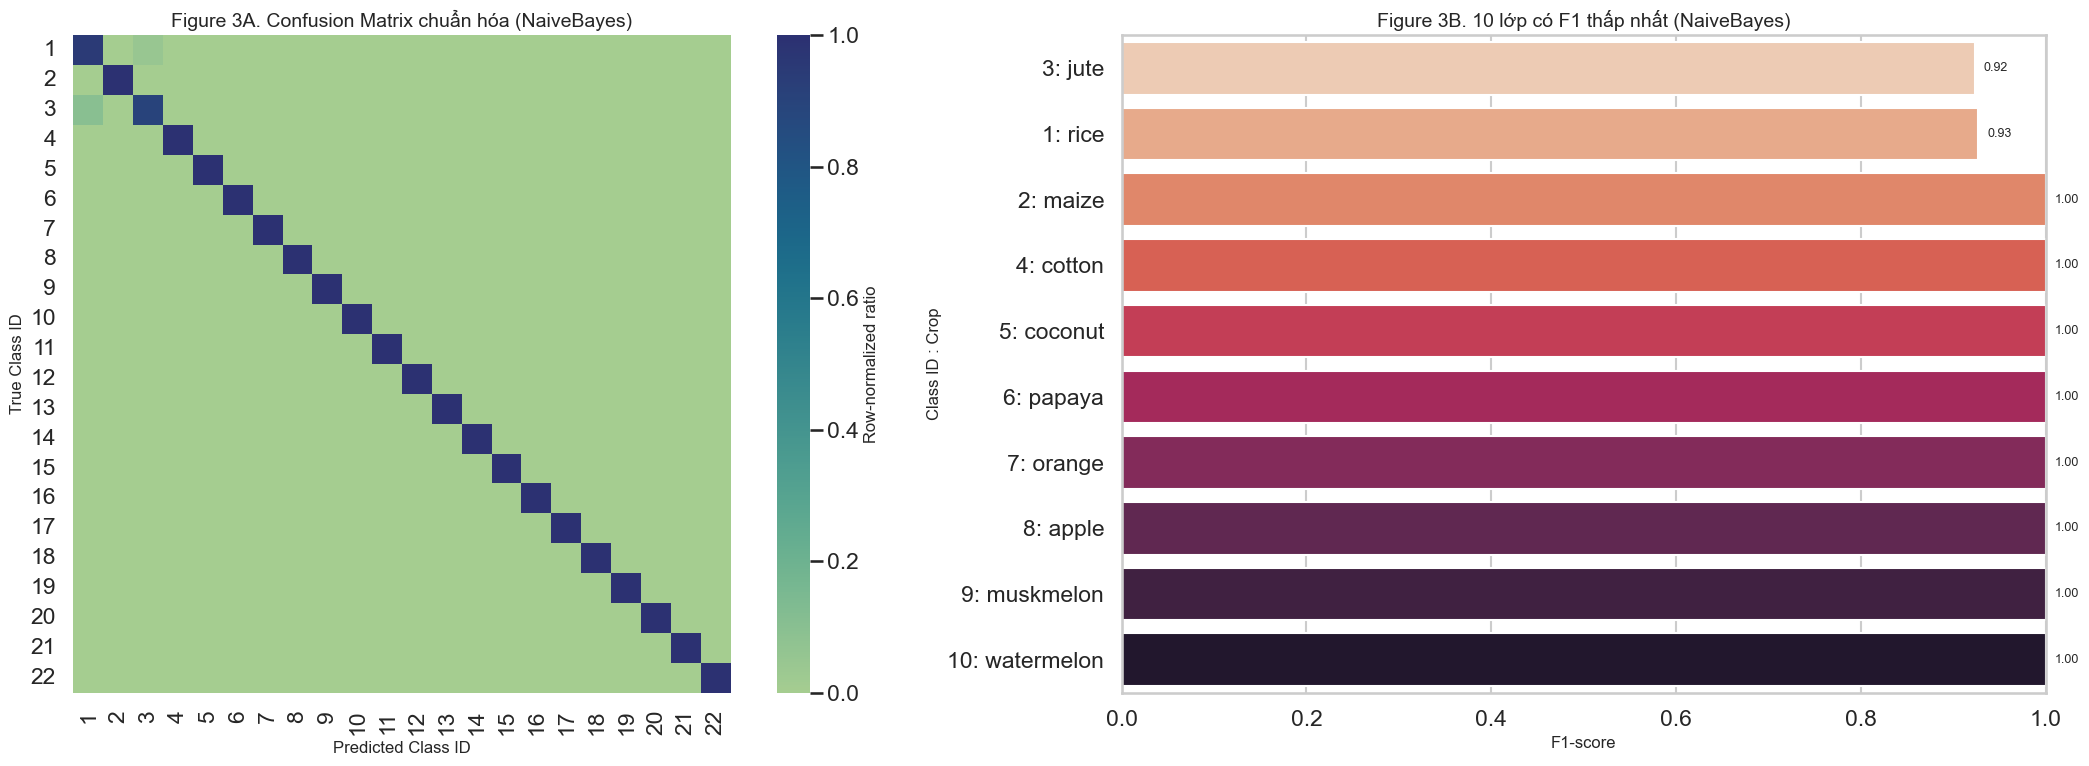

In [24]:
# Figure 3: Chẩn đoán mô hình tốt nhất (test hold-out)
best_cm = test_artifacts[best_model_name]["confusion_matrix"].astype(float)
best_cm_norm = best_cm / best_cm.sum(axis=1, keepdims=True)
best_cm_norm = np.nan_to_num(best_cm_norm)

tick_labels = sorted(clean_df["crop_id"].unique())

detail_report_df = pd.DataFrame(test_artifacts[best_model_name]["classification_report"]).T
class_report_df = detail_report_df[detail_report_df.index.str.isdigit()].copy()
class_report_df.index = class_report_df.index.astype(int)
class_report_df["label"] = class_report_df.index.map(lambda cid: f"{cid}: {ID_TO_CROP.get(cid, 'unknown')}")
worst_f1_df = class_report_df.sort_values("f1-score", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    best_cm_norm,
    cmap="crest",
    vmin=0,
    vmax=1,
    square=True,
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    cbar_kws={"label": "Row-normalized ratio"},
    ax=axes[0],
)
axes[0].set_title(f"Figure 3A. Confusion Matrix chuẩn hóa ({best_model_name})")
axes[0].set_xlabel("Predicted Class ID")
axes[0].set_ylabel("True Class ID")
axes[0].tick_params(axis="x", rotation=90)
axes[0].tick_params(axis="y", rotation=0)

sns.barplot(
    data=worst_f1_df,
    y="label",
    x="f1-score",
    palette="rocket_r",
    ax=axes[1],
)
axes[1].set_title(f"Figure 3B. 10 lớp có F1 thấp nhất ({best_model_name})")
axes[1].set_xlabel("F1-score")
axes[1].set_ylabel("Class ID : Crop")
axes[1].set_xlim(0, 1)
for i, value in enumerate(worst_f1_df["f1-score"]):
    axes[1].text(value + 0.01, i, f"{value:.2f}", va="center", fontsize=9)

plt.tight_layout()
save_publication_figure(fig, "fig03_best_model_confusion_and_low_f1_classes.png")
plt.show()

In [25]:
# Figure 4: Feature importance (nếu mô hình hỗ trợ)
importance_df = None

if hasattr(best_model, "feature_importances_"):
    importance_values = np.asarray(best_model.feature_importances_)
    importance_df = pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "importance": importance_values,
        }
    ).sort_values("importance", ascending=True)

elif hasattr(best_model, "coef_"):
    coef_values = np.asarray(best_model.coef_)
    if coef_values.ndim == 2:
        coef_values = np.mean(np.abs(coef_values), axis=0)
    importance_df = pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "importance": coef_values,
        }
    ).sort_values("importance", ascending=True)

if importance_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis", ax=ax)
    ax.set_title(f"Figure 4. Mức độ quan trọng đặc trưng ({best_model_name})")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    x_offset = importance_df["importance"].max() * 0.02 if importance_df["importance"].max() > 0 else 0.01
    for i, value in enumerate(importance_df["importance"]):
        ax.text(value + x_offset, i, f"{value:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    save_publication_figure(fig, "fig04_feature_importance.png")
    plt.show()

    display(importance_df.sort_values("importance", ascending=False))
else:
    print(
        f"{best_model_name} không hỗ trợ feature importance trực tiếp (ví dụ SVM kernel RBF). "
        "Nếu cần phân tích sâu hơn, có thể dùng permutation importance."
    )

NaiveBayes không hỗ trợ feature importance trực tiếp (ví dụ SVM kernel RBF). Nếu cần phân tích sâu hơn, có thể dùng permutation importance.


## 8) Lưu mô hình, output và log

Bước triển khai sẽ:
- Tạo phiên bản mới trong thư mục `models/versions/<version>`.
- Lưu `model.pkl`, `standscaler.pkl`, `minmaxscaler.pkl`.
- Lưu `history.csv`, `nested_cv_fold_metrics.csv`, `outlier_stats.csv`.
- Lưu `training_metrics.json` có mô tả protocol nested CV + hold-out test 20%.
- Cập nhật `models/latest_version.txt` và chạy smoke test bằng artifact vừa lưu.

In [15]:
import shutil

run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v{run_timestamp}"

model_root = Path(CONFIG.model_root)
version_dir = model_root / "versions" / model_version
output_dir = Path(CONFIG.output_root) / run_timestamp
version_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# Lưu mô hình và scaler theo tên tương thích production.
with open(version_dir / "model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(version_dir / "standscaler.pkl", "wb") as f:
    pickle.dump(bundle["standard_scaler"], f)

with open(version_dir / "minmaxscaler.pkl", "wb") as f:
    pickle.dump(bundle["minmax_scaler"], f)

# Lưu log huấn luyện/đánh giá.
history_df.to_csv(output_dir / "history.csv", index=False)
nested_fold_metrics_df.to_csv(output_dir / "nested_cv_fold_metrics.csv", index=False)
outlier_stats.to_csv(output_dir / "outlier_stats.csv", index=False)

best_row = history_df.loc[history_df["model"] == best_model_name].iloc[0]
metrics_payload = {
    "training_timestamp": run_timestamp,
    "selected_model": best_model_name,
    "model_version": model_version,
    "evaluation_protocol": {
        "test_holdout_ratio": CONFIG.test_size,
        "nested_cv": {
            "outer_folds": CONFIG.outer_folds,
            "inner_folds": CONFIG.inner_folds,
            "inner_scoring": "f1_macro",
        },
    },
    "dataset_path": str(data_path),
    "feature_columns": FEATURE_COLUMNS,
    "target_mapping": CROP_TO_ID,
    "clean_summary": clean_summary,
    "model_history": history,
    "best_model_metrics": {
        "accuracy_train_mean": float(best_row["accuracy_train_mean"]),
        "accuracy_val_mean": float(best_row["accuracy_val_mean"]),
        "accuracy_test": float(best_row["accuracy_test"]),
        "precision_val_mean": float(best_row["precision_val_mean"]),
        "recall_val_mean": float(best_row["recall_val_mean"]),
        "f1_val_mean": float(best_row["f1_val_mean"]),
        "precision_test": float(best_row["precision_test"]),
        "recall_test": float(best_row["recall_test"]),
        "f1_test": float(best_row["f1_test"]),
        "generalization_gap": float(best_row["generalization_gap"]),
        "val_balance_score": float(best_row["val_balance_score"]),
    },
    "split": {
        "trainval_size": int(len(bundle["X_train"])),
        "test_size": int(len(bundle["X_test"])),
    },
}

with open(version_dir / "training_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

with open(model_root / "latest_version.txt", "w", encoding="utf-8") as f:
    f.write(model_version)

for file_name in ["model.pkl", "standscaler.pkl", "minmaxscaler.pkl"]:
    shutil.copyfile(version_dir / file_name, model_root / file_name)

print("Đã lưu artifact:")
print(f"- Thư mục phiên bản: {version_dir}")
print(f"- Thư mục log: {output_dir}")
print(f"- latest_version.txt -> {model_version}")

# Smoke test với artifact vừa lưu.
with open(version_dir / "model.pkl", "rb") as f:
    smoke_model = pickle.load(f)
with open(version_dir / "standscaler.pkl", "rb") as f:
    smoke_sc = pickle.load(f)
with open(version_dir / "minmaxscaler.pkl", "rb") as f:
    smoke_mm = pickle.load(f)

sample_row = clean_df[FEATURE_COLUMNS].iloc[[0]].values
sample_mm = smoke_mm.transform(sample_row)
sample_scaled = smoke_sc.transform(sample_mm)
smoke_pred_id = int(smoke_model.predict(sample_scaled)[0])

print(f"Dự đoán kiểm tra nhanh crop_id: {smoke_pred_id}")
print(f"Dự đoán kiểm tra nhanh crop_name: {ID_TO_CROP.get(smoke_pred_id, 'unknown')}")

Saved artifacts:
- Version directory: models\versions\v20260427_014043
- Output logs: training_outputs\20260427_014043
- latest_version.txt -> v20260427_014043
Smoke prediction crop_id: 1
Smoke prediction crop_name: rice


## 9) Gợi ý triển khai vào predict server

Sau khi train xong:
1. Server Flask đọc mô hình theo phiên bản (`ML_MODEL_VERSION` hoặc `latest_version.txt`).
2. Muốn dùng bản mới ngay: giữ nguyên `models/latest_version.txt` vừa cập nhật.
3. Khởi động lại ML server để nạp artifact mới.
4. Test `/model-info` và `/predict` để xác nhận phiên bản mô hình đang phục vụ.

Notebook này hiện đánh giá khách quan 4 mô hình (Random Forest, Naive Bayes, KNN, SVM) bằng nested CV + hold-out test 20%, đồng thời phân tích trade-off precision/recall/F1 trên cả validation và testing.